# Lesson 3: Loops

## *The Retry and Reason-Act Cycle*

---

### Why This Matters

In Lesson 2, our graph made a one-shot decision and moved forward. But what about situations where the first attempt is not good enough?

Real intelligence often requires **iteration** - trying, evaluating, improving, and trying again until the result is acceptable.

---

### The Mental Model

> **Think of a chef tasting soup.**
>
> She adds salt, tastes it. Not enough. Adds pepper, tastes again. Still needs something. Adds a squeeze of lemon, tastes one more time. Perfect - now she moves on to plating.
>
> The tasting is the **conditional check**. Going back to add seasoning is the **loop**. She does not move forward until the condition ("tastes good") is met.

In LangGraph, a loop is nothing exotic - it is simply a conditional edge that points **backward** to a previous node instead of forward.

---

### What We Will Build

A password strength validator that keeps improving a weak password until it meets all requirements (or gives up after max attempts).

```
START -> check_password -> [strong enough?]
                              |
                   +----------+----------+
                   |                     |
               accept            suggest_improvement
                   |                     |
                  END          check_password (LOOP)
```

---

## Step 1: Setup

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

C:\Users\sk72\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


---

## Step 2: Define State

Our State tracks the iterative improvement process:

| Field | Purpose |
|:---|:---|
| `password` | The current password being evaluated |
| `is_strong` | Whether it passes all checks |
| `feedback` | What is wrong with it |
| `attempts` | How many times we have looped |

> **Critical**: The `attempts` counter is your **circuit breaker**. Without it, a bug could make your graph spin forever. Always have an exit condition in loops.

In [2]:
class State(TypedDict):
    password: str
    is_strong: bool
    feedback: str
    attempts: int

---

## Step 3: Define the Nodes

Two workers forming the iteration cycle:

| Node | Role | Real-World Equivalent |
|:---|:---|:---|
| `check_password` | Evaluates against rules, writes feedback | Teacher grading homework |
| `suggest_improvement` | Reads feedback, fixes the password | Student revising their work |

> **Key Insight**: `suggest_improvement` modifies the password in State. When the loop goes back to `check_password`, it sees the *updated* version. This is the "reason-act" pattern: reason about what is wrong, act to fix it, then reason again.

In [3]:
def check_password(state: State):
    """Evaluates password strength. Like a teacher grading homework."""
    password = state["password"]
    issues = []

    if len(password) < 8:
        issues.append("too short (need 8+ characters)")
    if not any(c.isupper() for c in password):
        issues.append("needs an uppercase letter")
    if not any(c.isdigit() for c in password):
        issues.append("needs a number")
    if not any(c in "!@#$%^&*" for c in password):
        issues.append("needs a special character (!@#$%^&*)")

    if not issues:
        return {"is_strong": True, "feedback": "Password is strong!"}
    else:
        return {"is_strong": False, "feedback": ", ".join(issues)}


def suggest_improvement(state: State):
    """Improves the password based on feedback. Like a student revising their work."""
    password = state["password"]
    feedback = state["feedback"]

    # Simple rule-based improvements
    if "too short" in feedback:
        password = password + "xyz"
    if "uppercase" in feedback:
        password = password[0].upper() + password[1:]
    if "number" in feedback:
        password = password + "42"
    if "special character" in feedback:
        password = password + "!"

    return {"password": password, "attempts": state["attempts"] + 1}

---

## Step 4: The Routing Function (With Loop Logic)

After checking the password, the routing function asks three questions in order:

| Condition | Result | Next Node |
|:---|:---|:---|
| Password is strong | Done, move forward | `accept` |
| Too many attempts | Give up gracefully | `accept` |
| Still weak, retries remain | Try again | `suggest_improvement` |

> **Safety Rule**: Never build a loop without a maximum iteration count. An infinite loop in production will burn through your compute budget.

In [4]:
MAX_ATTEMPTS = 3

def should_continue(state: State) -> str:
    """The traffic cop at the loop junction."""
    if state["is_strong"]:
        return "accept"  # Password passed, move forward
    elif state["attempts"] >= MAX_ATTEMPTS:
        return "accept"  # Give up after max attempts
    else:
        return "suggest_improvement"  # Loop back and try again


def accept(state: State):
    """Final node - just reports the result."""
    if state["is_strong"]:
        return {"feedback": f"Accepted! Final password: {state['password']}"}
    else:
        return {"feedback": f"Gave up after {state['attempts']} attempts. Best effort: {state['password']}"}

---

## Step 5: Build the Graph

> **The difference from Lesson 2**: One of the conditional edge paths points **backward** to a node that already ran. That backward arrow is what creates the loop.

In [5]:
workflow = StateGraph(State)

# Register nodes
workflow.add_node("check_password", check_password)
workflow.add_node("suggest_improvement", suggest_improvement)
workflow.add_node("accept", accept)

# Entry point
workflow.add_edge(START, "check_password")

# The conditional edge creates the loop
# Path map tells the renderer both possible destinations
workflow.add_conditional_edges(
    "check_password",
    should_continue,
    {"accept": "accept", "suggest_improvement": "suggest_improvement"}
)

# After improving, go back to check (this creates the loop)
workflow.add_edge("suggest_improvement", "check_password")

# Accept leads to END
workflow.add_edge("accept", END)

app = workflow.compile()

---

## Step 6: Test the Loop

Two scenarios to observe different behaviors:
1. A weak password (`"cat"`) that requires multiple improvement iterations
2. An already-strong password that passes on the first check (no loop)

In [6]:
# Start with a very weak password
result = app.invoke({
    "password": "cat",
    "is_strong": False,
    "feedback": "",
    "attempts": 0
})

print(f"Starting password: 'cat'")
print(f"Final password: '{result['password']}'")
print(f"Attempts taken: {result['attempts']}")
print(f"Result: {result['feedback']}")
print(f"Is strong: {result['is_strong']}")

Starting password: 'cat'
Final password: 'Catxyz42!'
Attempts taken: 1
Result: Accepted! Final password: Catxyz42!
Is strong: True


In [7]:
# Start with an already-strong password (no loop needed)
result = app.invoke({
    "password": "MyStr0ng!Pass",
    "is_strong": False,
    "feedback": "",
    "attempts": 0
})

print(f"Starting password: 'MyStr0ng!Pass'")
print(f"Attempts taken: {result['attempts']}")
print(f"Result: {result['feedback']}")

Starting password: 'MyStr0ng!Pass'
Attempts taken: 0
Result: Accepted! Final password: MyStr0ng!Pass


---

## Step 7: Visualize the Graph

Look for the **backward arrow** from `suggest_improvement` back to `check_password`. That cycle is the loop.

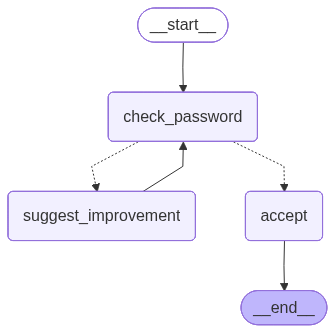

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What We Built

A graph that **does not give up on the first try**. It loops, improves, and checks again - just like iterative problem-solving in the real world.

---

### The Loop Recipe

| Ingredient | Purpose |
|:---|:---|
| Conditional edge pointing backward | Creates the cycle |
| Max-attempts counter | Prevents infinite loops |
| State mutation each iteration | Gives the next pass fresh data to work with |

---

### Introducing the ReAct Pattern

This lesson planted a seed that becomes the core of modern AI agents. The loop we built follows the **ReAct** (Reason + Act) pattern:

```
Reason:  "Is the password strong enough?" (check_password evaluates)
Act:     "No, let me fix it." (suggest_improvement modifies)
Observe: "Let me check again." (loop back to check_password)
Repeat until done.
```

In Lesson 5, we will see this same loop with an LLM as the reasoner and real tools as the actions. But the *structure* is identical to what you just built here. Every sophisticated AI agent - from ChatGPT's code interpreter to autonomous research assistants - runs this exact Reason-Act-Observe loop under the hood.

> **Remember**: ReAct is not a library or a special API. It is simply a loop where each iteration reasons about the current state, takes action, and checks the result. You already know how to build it.

---

### Key Takeaways

> 1. A loop is just a conditional edge pointing **backward** to an earlier node
> 2. Always include a max-attempts safety valve
> 3. Each loop iteration updates State, giving the next iteration new data
> 4. This is the structural foundation of the **ReAct** pattern used in all modern AI agents

---

**Next Lesson**: We replace our simple keyword checks with an actual LLM. Lesson 4 makes the model the decision-maker.